# Filter Visualization
This notebook visualizes the effects of various filters.

In [2]:
import numpy as np
from matplotlib import pyplot as plt

Basic starting waveforms

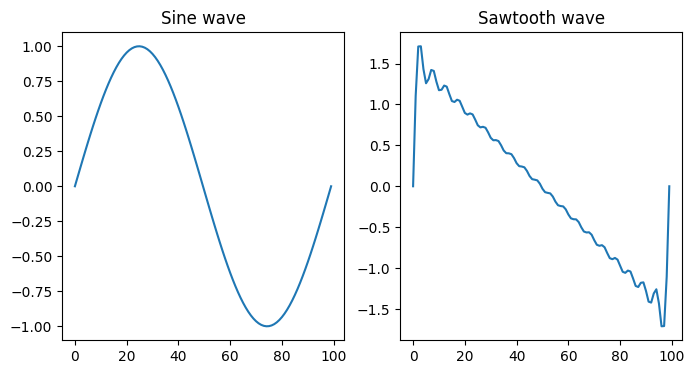

In [12]:
SIGNAL_LEN = 100
sin = np.sin(np.linspace(0, 2 * np.pi, SIGNAL_LEN))
saw = np.sum(np.vstack([np.sin(np.linspace(0, 2 * i * np.pi, SIGNAL_LEN))/i for i in range(1, 20)]), axis=0)
fig, ax = plt.subplots(1, 2)
ax[0].plot(range(SIGNAL_LEN), sin)
ax[0].set_title("Sine wave")
ax[1].plot(range(SIGNAL_LEN), saw)
ax[1].set_title("Sawtooth wave")
fig.set_size_inches(8.0, 4.0)
plt.show()

## Differentiator filter
An ideal differentiator filter should have the frequency response given below (where $(-1, 1)$ represents the Nyquist bounds). This ideal frequency response can be approximated by a two-tap FIR highpass filter, with coefficients $(1, -1)$, i.e. $$y(n)=x(n)-x(n-1)$$

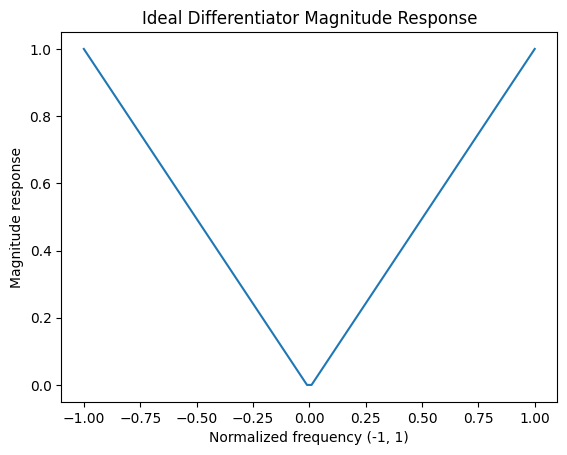

In [4]:
y = np.concatenate((np.linspace(1.0, 0.0, SIGNAL_LEN//2), np.linspace(0.0, 1.0, SIGNAL_LEN//2)))
x = np.linspace(-1.0, 1.0, SIGNAL_LEN)
fig, ax = plt.subplots()
ax.plot(x, y)
ax.set_xlabel("Normalized frequency (-1, 1)")
ax.set_ylabel("Magnitude response")
ax.set_title("Ideal Differentiator Magnitude Response")
plt.show()

We can see that this works quite well with an example. Consider what happens when we apply this simple differentiator to a sine wave:

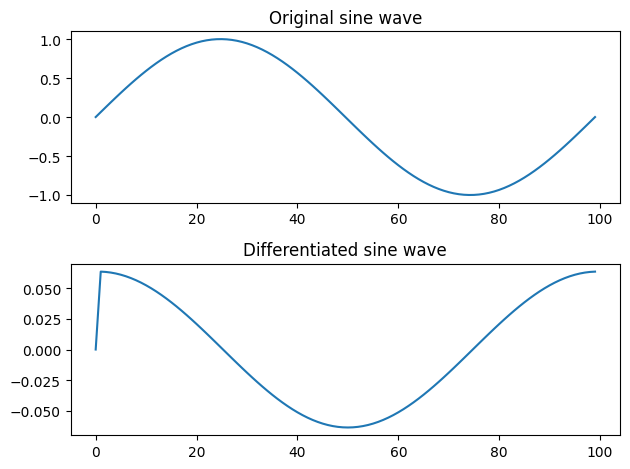

In [6]:
delayed_sin = np.concatenate(([0], sin[:-1]))
differentiated = sin - delayed_sin
fig, ax = plt.subplots(2)
ax[0].plot(range(SIGNAL_LEN), sin)
ax[0].set_title("Original sine wave")
ax[1].plot(range(SIGNAL_LEN), differentiated)
ax[1].set_title("Differentiated sine wave")
plt.tight_layout()
plt.show()

Here's what a differentiator does to a sawtooth:

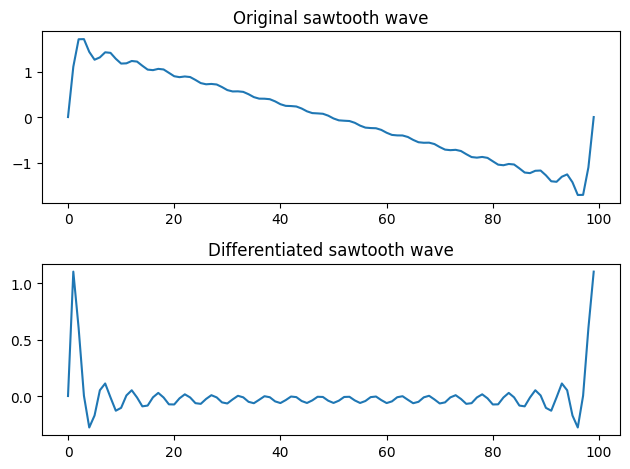

In [8]:
delayed_saw = np.concatenate(([0], saw[:-1]))
differentiated_saw = saw - delayed_saw
fig, ax = plt.subplots(2)
ax[0].plot(range(SIGNAL_LEN), saw)
ax[0].set_title("Original sawtooth wave")
ax[1].plot(range(SIGNAL_LEN), differentiated_saw)
ax[1].set_title("Differentiated sawtooth wave")
plt.tight_layout()
plt.show()

## Integrator
An ideal integrator has a magnitude response that looks like the plot below. Note that the gain at 0 Hz is actually infinite, which makes intuitive sense. Of course, the only way to get a filter with this magnitude response is to use an IIR filter with a pole on the unit circle, which will be unstable. So we will have to use a "leaky" integrator. A simple leaky integrator is given with the difference equation $$y(n)=x(n) + by(n-1)$$ where $b$ is a "leak" coefficient. If $b$ is 1, there is no leak. For $b<1$ the pole moves inside the unit circle and there is not infinite gain at DC.

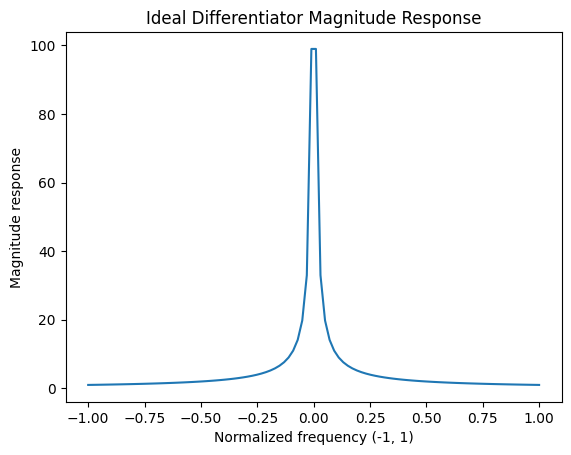

In [7]:
x = np.linspace(-1.0, 1.0, SIGNAL_LEN)
y = 1 / np.abs(x)
fig, ax = plt.subplots()
ax.plot(x, y)
ax.set_xlabel("Normalized frequency (-1, 1)")
ax.set_ylabel("Magnitude response")
ax.set_title("Ideal Differentiator Magnitude Response")
plt.show()

An example of this applied to a sine wave, with leak coefficient 1 (no leak). Try other leak coefficients--the best option is something very close to 1, like 0.999.

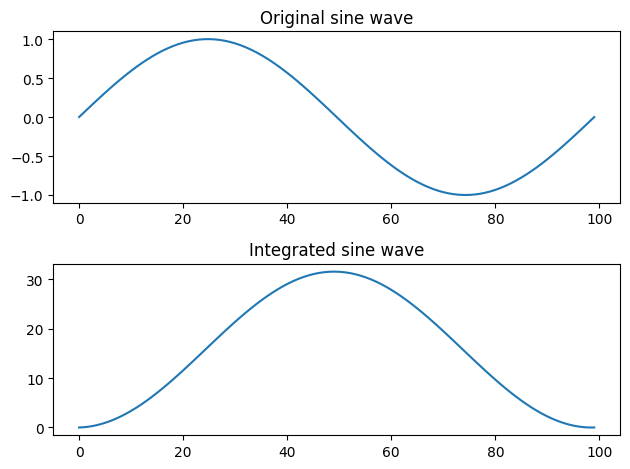

In [11]:
LEAK = 1
integrated_sin = np.zeros((SIGNAL_LEN))
integrated_sin[0] = sin[0]
for i in range(1, SIGNAL_LEN):
    integrated_sin[i] = sin[i] + LEAK * integrated_sin[i-1]
fig, ax = plt.subplots(2)
ax[0].plot(range(SIGNAL_LEN), sin)
ax[0].set_title("Original sine wave")
ax[1].plot(range(SIGNAL_LEN), integrated_sin)
ax[1].set_title("Integrated sine wave")
plt.tight_layout()
plt.show()

And the same, for a sawtooth wave:

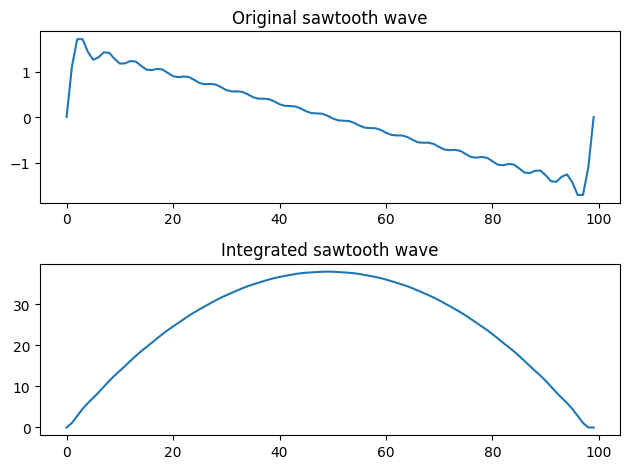

In [12]:
integrated_saw = np.zeros((SIGNAL_LEN))
integrated_saw[0] = saw[0]
for i in range(1, SIGNAL_LEN):
    integrated_saw[i] = saw[i] + LEAK * integrated_saw[i-1]
fig, ax = plt.subplots(2)
ax[0].plot(range(SIGNAL_LEN), saw)
ax[0].set_title("Original sawtooth wave")
ax[1].plot(range(SIGNAL_LEN), integrated_saw)
ax[1].set_title("Integrated sawtooth wave")
plt.tight_layout()
plt.show()

## FIR Lowpass Filter
For this example, we'll use an 8-tap FIR lowpass filter, with a difference equation of $$y(n)=\sum_{k=0}^{K-1} a_k x(n-k),\hspace{1em} a_k=\frac{1}{K}$$

In [3]:
def fir(coefs: np.ndarray, signal: np.ndarray) -> np.ndarray:
    delays = [signal]
    for i in range(1, coefs.size):
        delays.append(np.concatenate(([0], delays[i-1][:-1])))
    result = np.sum(np.vstack(delays).T * coefs, axis=1)
    return result

Consider a simple stepped signal, and the filter applied to it. The filter doesn't remove the sharp edges, but it does make things somewhat smoother.

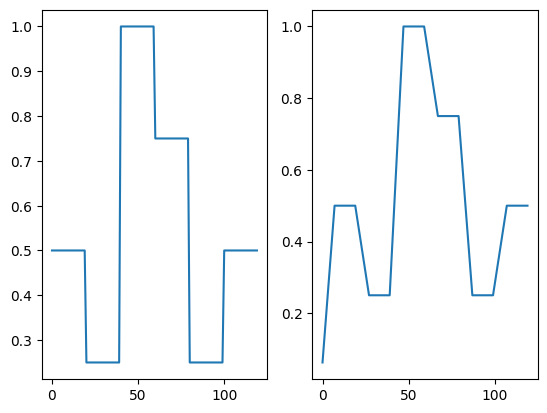

In [4]:
fir_coefs = np.array([1/8 for _ in range(8)])
stepped = np.concat([np.ones((20)) * val for val in [1/2, 1/4, 1, 3/4, 1/4, 1/2]])
fig, ax = plt.subplots(1, 2)
ax[0].plot(range(stepped.size), stepped)
ax[1].plot(range(stepped.size), fir(fir_coefs, stepped))
plt.show()

What about a Butterworth lowpass filter? It turns out that adds some annoying jitter to the waveform. Perhaps linear phase helps us avoid this jitter.

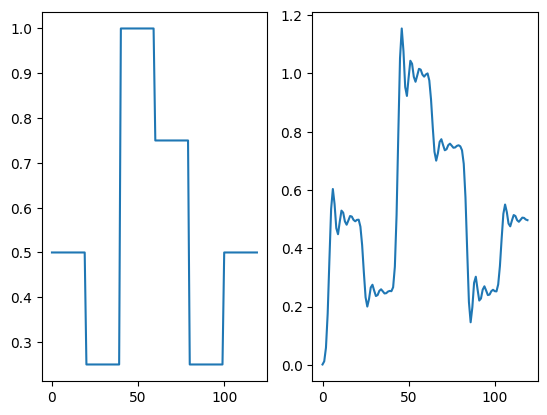

In [8]:
import scipy.signal as signal
butter_filt = signal.butter(8, 200, 'low', output='sos', fs=1000)
fig, ax = plt.subplots(1, 2)
ax[0].plot(range(stepped.size), stepped)
ax[1].plot(range(stepped.size), signal.sosfilt(butter_filt, stepped))
plt.show()

We can test this somewhat by trying a Bessel filter, which turns out to be much better.

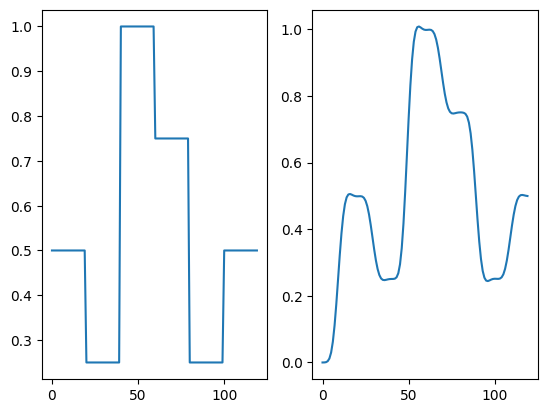

In [10]:
bessel_filt = signal.bessel(8, 100, 'low', output='sos', fs=1000)
b_filtered = signal.sosfilt(bessel_filt, stepped)
fig, ax = plt.subplots(1, 2)
ax[0].plot(range(stepped.size), stepped)
ax[1].plot(range(stepped.size), b_filtered)
plt.show()

Now we can try differentiating the Bessel-filtered signal:

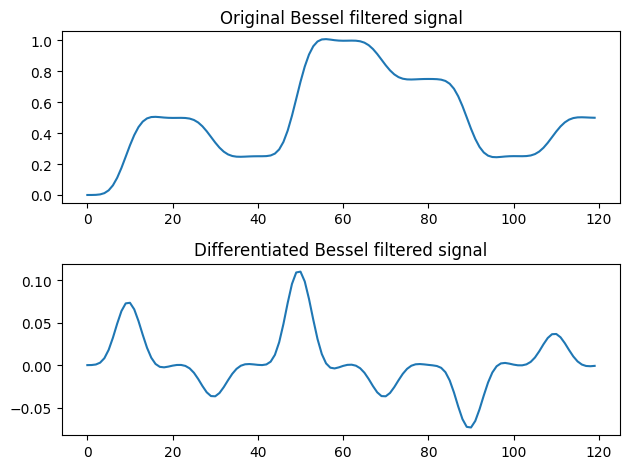

In [15]:
delayed_bessel = np.concatenate(([0], b_filtered[:-1]))
differentiated_bessel = b_filtered - delayed_bessel
fig, ax = plt.subplots(2)
ax[0].plot(range(b_filtered.size), b_filtered)
ax[0].set_title("Original Bessel filtered signal")
ax[1].plot(range(b_filtered.size), differentiated_bessel)
ax[1].set_title("Differentiated Bessel filtered signal")
plt.tight_layout()
plt.show()